In [ ]:
# vamos a construir un primer modelo base con el que comparar.
# para ello nos vamos a basar en modelos de expertos FICO.
# puntajes entre 300 y 850, con un puntaje de corte de 700.

import pandas as pd
import numpy as np


In [ ]:
#Leemos el dataset
df = pd.read_csv('data/df_test_small.csv')

In [ ]:
[n for n in df.columns if 'fico' in n]

['fico_range_low',
 'fico_range_high',
 'last_fico_range_high',
 'last_fico_range_low',
 'sec_app_fico_range_low',
 'sec_app_fico_range_high']

In [ ]:
# nos quedamos con puntajes fico
df_fico = ( df
        .loc[:,["fico_range_low", "fico_range_high", "loan_status"]]
        .assign(prob_low = lambda x: (x.fico_range_low - 300) / (850 - 300))
        .assign(prob_high = lambda x: (x.fico_range_high - 300) / (850 - 300))
        .assign(prob = lambda x: (x.prob_low + x.prob_high) / 2)
        .assign(loan_paid = lambda x: np.where(x.loan_status == "Fully Paid", 1, 0))
)

In [ ]:
df_fico.head()

,fico_range_low,fico_range_high,loan_status,prob_low,prob_high,prob,loan_paid
0,695.0,699.0,Charged Off,0.718182,0.725455,0.721818,0
1,705.0,709.0,Fully Paid,0.736364,0.743636,0.740000,1
2,720.0,724.0,Charged Off,0.763636,0.770909,0.767273,0
3,715.0,719.0,Fully Paid,0.754545,0.761818,0.758182,1
4,660.0,664.0,Charged Off,0.654545,0.661818,0.658182,0


In [ ]:
# FICO standard cut-off is 670, so we can use that as a threshold to predict whether a loan will be paid or not.
df_fico = df_fico.assign(prediction = lambda x: np.where(x.prob > 0.67, 1, 0))
df_fico.head()

,fico_range_low,fico_range_high,loan_status,prob_low,prob_high,prob,loan_paid,prediction
0,695.0,699.0,Charged Off,0.718182,0.725455,0.721818,0,1
1,705.0,709.0,Fully Paid,0.736364,0.743636,0.740000,1,1
2,720.0,724.0,Charged Off,0.763636,0.770909,0.767273,0,1
3,715.0,719.0,Fully Paid,0.754545,0.761818,0.758182,1,1
4,660.0,664.0,Charged Off,0.654545,0.661818,0.658182,0,0


In [ ]:
# metrics
from sklearn.metrics import classification_report
print(classification_report(df_fico.loan_paid, df_fico.prediction))

              precision    recall  f1-score   support

           0       0.26      0.24      0.25      3997
           1       0.81      0.84      0.83     16003

    accuracy                           0.72     20000
   macro avg       0.54      0.54      0.54     20000
weighted avg       0.70      0.72      0.71     20000



AUC: 0.592121698597575


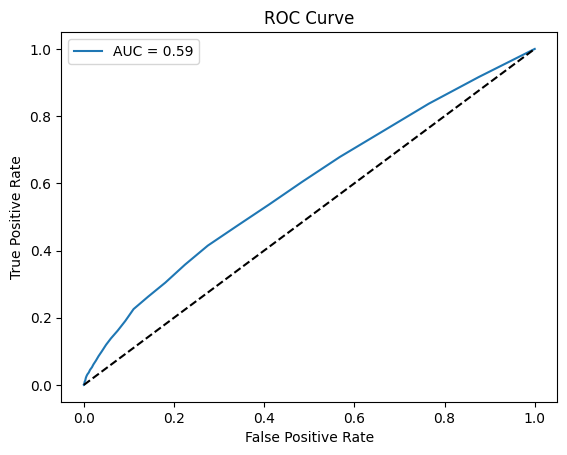

In [ ]:
# ahora el area bajo la curva ROC y pintamos la curva ROC
from sklearn.metrics import roc_auc_score, roc_curve
auc = roc_auc_score(df_fico.loan_paid, df_fico.prob)
print(f"AUC: {auc}")
fpr, tpr, thresholds = roc_curve(df_fico.loan_paid, df_fico.prob)
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

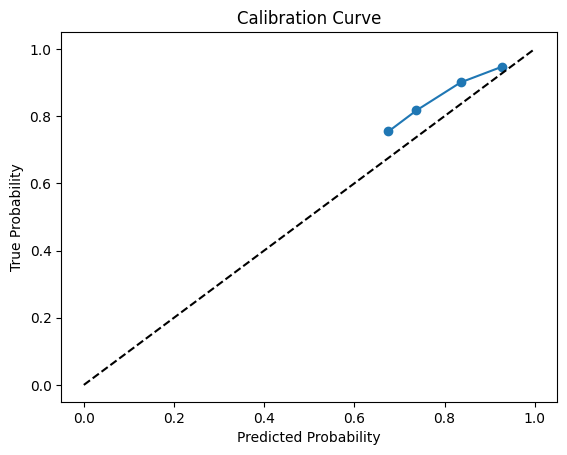

In [ ]:
# por ultimos calibracion de probabilidades, con una curva de calibracion
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(df_fico.loan_paid, df_fico.prob, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Predicted Probability')
plt.ylabel('True Probability')
plt.title('Calibration Curve')
plt.show()

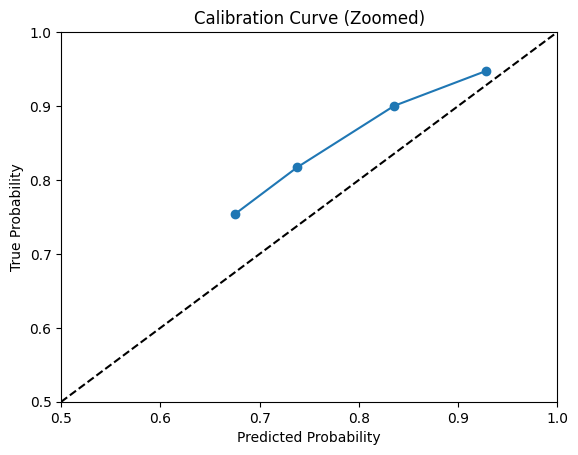

In [ ]:
# scale the graph to see only the relevant part
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim(0.5, 1)
plt.ylim(0.5, 1)
plt.xlabel('Predicted Probability')
plt.ylabel('True Probability')
plt.title('Calibration Curve (Zoomed)')
plt.show()